In [82]:
import sys
sys.path.append('../')
from tqdm import tqdm
import os
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from utilities import load_embedding, print_exams
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# 設置設備
device = torch.device('cuda:0')

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        # 生成嵌入文件名
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        # 轉換傳代類別為張量
        self.strainPassCats = convert_Pass2tensor(
            ('<cls>' + DataFrame['serumPassCat'] + '<eos>' + 
             DataFrame['virusPassCat'] + '<eos>').tolist()
        )
        
        # 標籤
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.emb_file_name_a[idx], self.emb_file_name_b[idx], 
                self.emb_file_name_c[idx], self.emb_file_name_d[idx], 
                self.strainPassCats[idx], self.labels[idx])

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1')
             .replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    
    for i in range(len(matrix_list)): 
        # 填充矩陣到最大長度
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list), max_len)
    return matrix, mask

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)
    return pd.DataFrame(merged_rows)

## 病毒进化可视化

In [86]:
def cluster_virus(df, vector, drop_duplicate=False):
    if drop_duplicate:
        df_arr = pd.DataFrame(vector, columns=[f'col_{i}' for i in range(vector.shape[1])])
        df_merged = pd.concat([df.reset_index(drop=True), df_arr], axis=1)
        df_merged["virusDate"] = pd.to_datetime(df_merged["virusDate"], errors="coerce")
        
        aggregate_dict = {col: 'first' for col in df_merged.columns if col != 'seq_c'}
        aggregate_dict['virusDate'] = 'min'
        df_agg = df_merged.groupby('seq_c').agg(aggregate_dict).reset_index()
        df = df_agg.iloc[:, :-2560]
        vector = np.array(df_agg.iloc[:, -2560:])

    # elbow_method(vector)
    
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(vector)

    k = 2
    labels = KMeans(n_clusters=k, random_state=441).fit_predict(X_2d)
    
    df_plot = pd.DataFrame(X_2d, columns=['x', 'y'])
    df_plot['cluster'] = labels.astype(str)
    df_plot['type'] = df['Type'].tolist()
    df_plot['virusDate'] = df['virusDate']
    df_plot['virusIslID'] = df['virusIslID'].tolist()

    return df_plot

def plot_virus_scatter(df_plot, color_map=None, save_path=None):
    plt.figure(figsize=(5, 3.5))

    order = ['Crick', 'CDC', 'CNIC']  # 你想要的顺序

    for t in order:
        subdf = df_plot[df_plot['type'] == t]  # 筛选对应类型的数据
        if len(subdf) == 0:
            continue  # 防止某类不存在时报错

        plt.scatter(subdf["x"], subdf["y"],
                    label=t,
                    c=color_map.get(t, "gray"),
                    s=8, alpha=0.45, lw=0)

    # ===== 样式 =====
    plt.xlabel("component-1", fontsize=14)
    plt.ylabel("component-2", fontsize=14)
    
    plt.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(0.98, 1), 
    markerscale=2, alignment='left')

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if save_path is not None:
        ext = os.path.splitext(save_path)[1].lower()

        if ext == '.png':
            plt.savefig(save_path, dpi=600, transparent=True,
                        pil_kwargs={"compress_level": 0}, bbox_inches="tight")
        elif ext == '.svg':
            plt.savefig(save_path, format='svg', bbox_inches="tight")
    else:
        plt.show()

def plot_virus_scatter_time(df_plot, save_path=None):
    """
    根据virusDate由浅到深绘制散点（自然色渐变：蓝→绿→黄）。
    """
    fig, ax = plt.subplots(figsize=(5, 3.5))

    # 确保时间格式并去掉NaT
    df_plot = df_plot.copy()
    df_plot["virusDate"] = pd.to_datetime(df_plot["virusDate"], errors="coerce")
    df_plot = df_plot.dropna(subset=["virusDate"])
    if df_plot.empty:
        raise ValueError("virusDate 列全部为空或无法解析为日期")

    # 按时间排序（保证后期点覆盖早期点）
    df_plot = df_plot.sort_values("virusDate")

    # 时间归一化（排除极端值，避免色带压缩）
    vmin = df_plot["virusDate"].quantile(0.05).timestamp()
    vmax = df_plot["virusDate"].quantile(0.95).timestamp()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # 自然色 colormap
    cmap = cm.get_cmap("cividis")

    # 绘制散点
    sc = ax.scatter(df_plot["x"], df_plot["y"],
                    c=df_plot["virusDate"].apply(lambda x: x.timestamp()),
                    cmap=cmap, norm=norm,
                    s=12, alpha=0.6, lw=0)

    # 颜色条
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))  # 只显示年份
    cbar.set_label("virusDate", fontsize=10)

    # 样式
    ax.set_xlabel("component-1", fontsize=14)
    ax.set_ylabel("component-2", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_aspect('equal')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, transparent=True,
                    bbox_inches="tight", pil_kwargs={"compress_level": 0})
    else:
        plt.show()


In [3]:
Crick_early = pd.read_csv('../../data/data_40/all.csv')
Crick_41 = pd.read_csv('../../data/data_40/Crick_41.csv')
Crick_42 = pd.read_csv('../../data/data_40/Crick_42.csv')
Crick_43 = pd.read_csv('../../data/data_40/Crick_43.csv')

In [53]:
df_early = Crick_early.copy().loc[(Crick_early['seq_c'].str.len() == 566),:].drop_duplicates(subset=['seq_id_c'])

df_41 = Crick_41.copy().loc[(Crick_41['seq_c'].str.len() == 566),:].drop_duplicates(subset=['seq_id_c'])
df_41['Type'] = df_41['Type'] + '_2024NH'

df_42 = Crick_42.copy().loc[(Crick_42['seq_c'].str.len() == 566),:].drop_duplicates(subset=['seq_id_c'])
df_42['Type'] = df_42['Type'] + '_2024SH'

df_43 = Crick_43.copy().loc[(Crick_43['seq_c'].str.len() == 566),:].drop_duplicates(subset=['seq_id_c'])
df_43['Type'] = df_43['Type'] + '_2025NH'

all_df = pd.concat([df_early, df_41, df_42, df_43]).reset_index(drop=True)

In [39]:
emb_dict_Crick = load_embedding("../../data/data_40/embedding_Crick", files=['matrix_' + ID + '.pt' for ID in df_early['seq_id_c'].tolist()])

Loading tensor: 100%|██████████| 5214/5214 [14:35<00:00,  5.96file/s]


In [ ]:
emb_dict_41 = load_embedding("../../data/data_40/embedding_41", files=['matrix_' + ID + '.pt' for ID in df_41['seq_id_c'].tolist()])
emb_dict_42 = load_embedding("../../data/data_40/embedding_42", files=['matrix_' + ID + '.pt' for ID in df_42['seq_id_c'].tolist()])
emb_dict_43 = load_embedding("../../data/data_40/embedding_43", files=['matrix_' + ID + '.pt' for ID in df_43['seq_id_c'].tolist()])

Loading tensor: 100%|██████████| 391/391 [01:05<00:00,  6.00file/s]


In [51]:
vector_Crick = np.stack([np.asarray(emb_dict_Crick['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_early['seq_id_c']])
vector_41 = np.stack([np.asarray(emb_dict_41['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_41['seq_id_c']])
vector_42 = np.stack([np.asarray(emb_dict_42['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_42['seq_id_c']])
vector_43 = np.stack([np.asarray(emb_dict_43['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_43['seq_id_c']])

all_vector = np.vstack([vector_Crick, vector_41, vector_42, vector_43])

In [55]:
color_map = {
        'H1N1': 'red',
        'H3N2': 'red',
        'H1N1_2024NH': 'cyan',
        'H3N2_2024NH': 'cyan',
        'H1N1_2024SH': 'magenta',
        'H3N2_2024SH': 'magenta',
        'H1N1_2025NH': 'orange',
        'H3N2_2025NH': 'orange'
    }

plot_df = cluster_virus(all_df, all_vector, drop_duplicate=True)

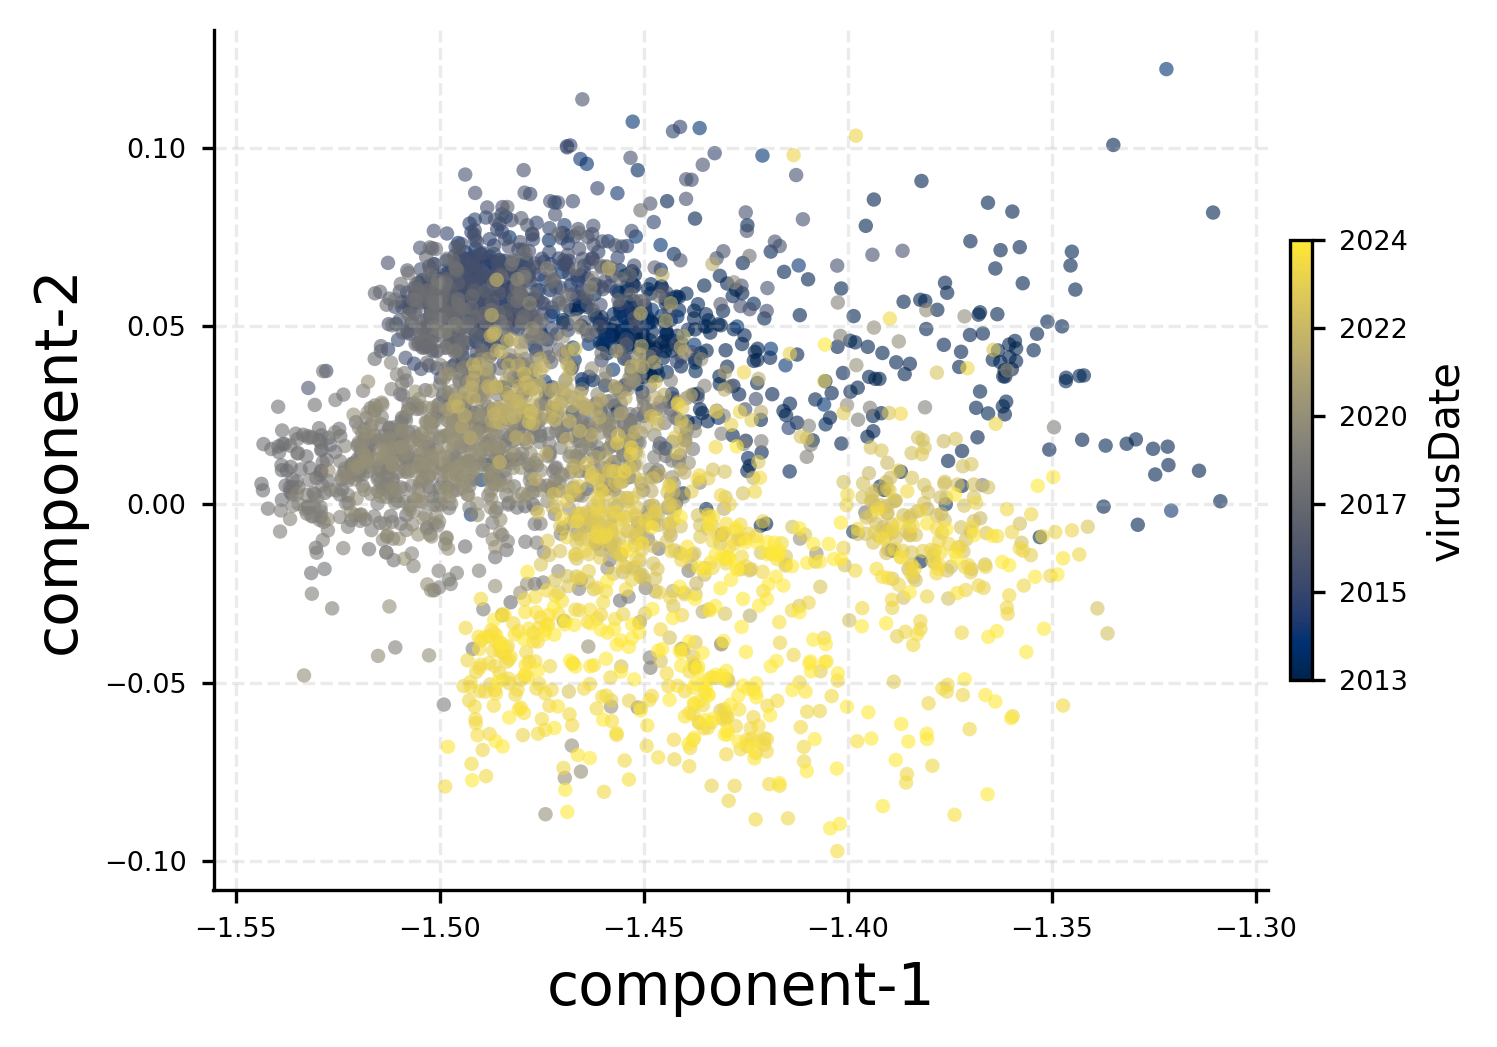

In [87]:
plot_df_filt = plot_df[plot_df['type'].isin(['H1N1', 'H1N1_2024NH', 'H1N1_2024SH', 'H1N1_2025NH'])]
plot_df_filt = plot_df_filt[plot_df_filt['virusDate'] >= '2003-08-31']
plot_df_filt = plot_df_filt[plot_df_filt['x'] < -1.3]
plot_df_filt = plot_df_filt[(plot_df_filt['y'] < 0.13) & (plot_df_filt['y'] > -0.1)]
# plot_virus_scatter_time(plot_df_filt)
plot_virus_scatter_time(plot_df_filt, save_path='H1N1_evo.png')

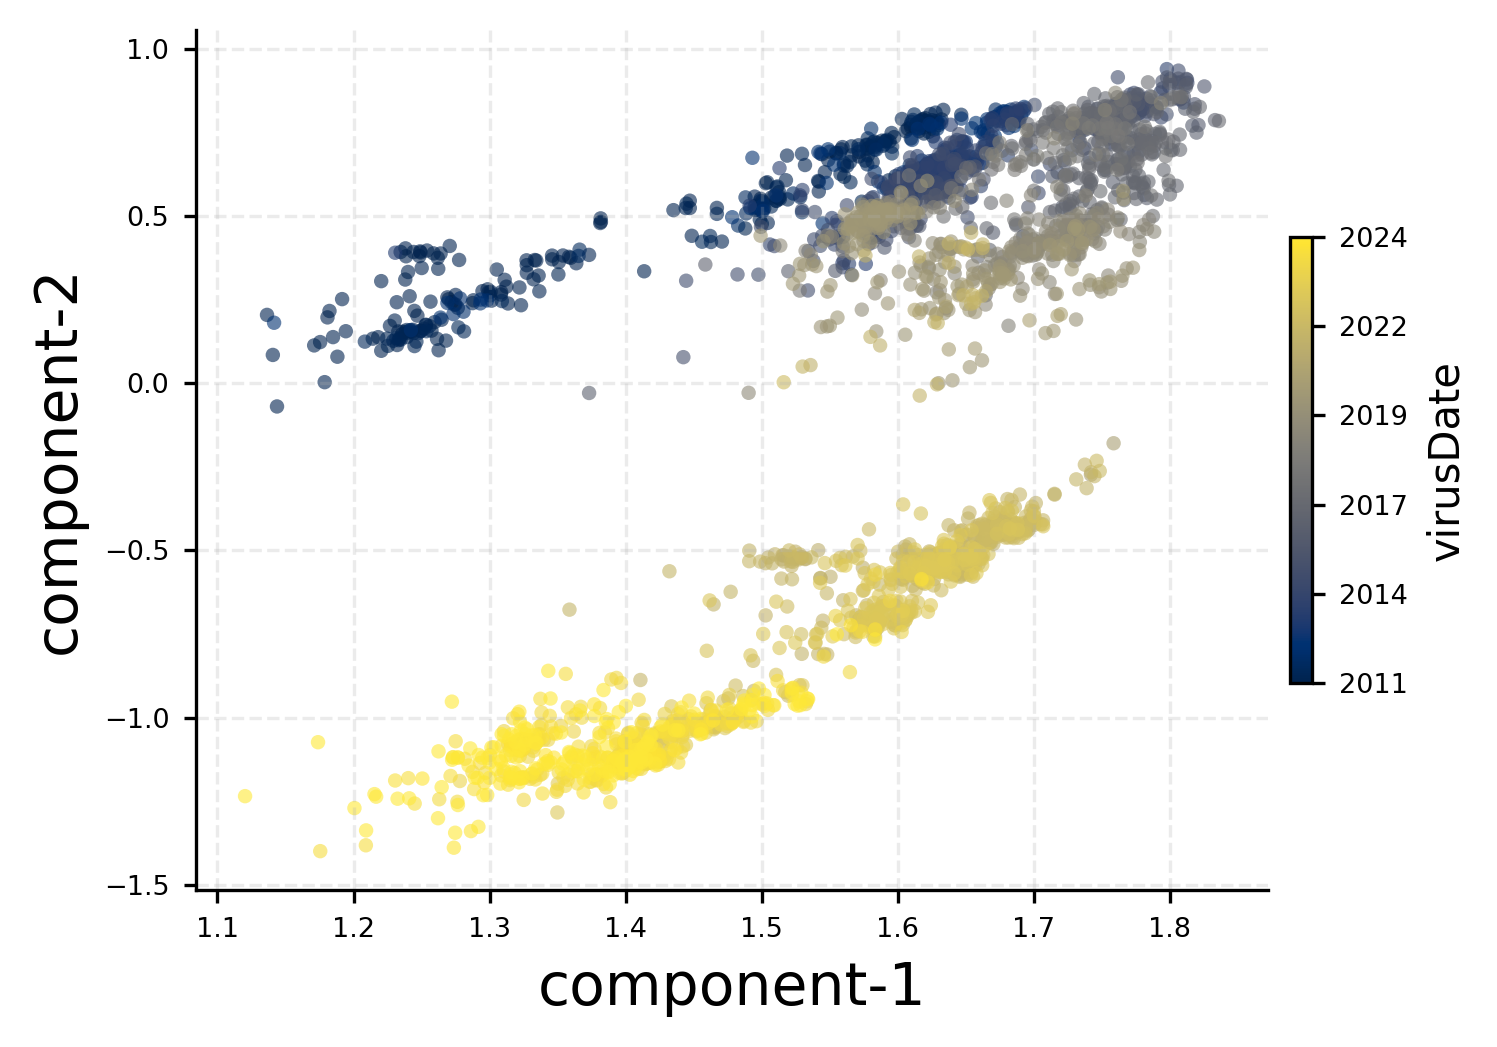

In [88]:
plot_df_filt = plot_df[plot_df['type'].isin(['H3N2', 'H3N2_2024NH', 'H3N2_2024SH', 'H3N2_2025NH'])]
plot_df_filt = plot_df_filt[plot_df_filt['x'] > 1.1]
plot_df_filt = plot_df_filt[plot_df_filt['y'] < 1]
plot_virus_scatter_time(plot_df_filt, save_path='H3N2_evo.png')